# Réduction de variance: préconditionnement et importance sampling

Sur on problème de modélisation classique en assurance, on illustre l'importance de l'erreur relative puis deux techniques de réduction de variance: 

- méthode par préconditionnement, 
- échantillonage d'importance (important pour les événements rares).

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme() 
from numpy.random import default_rng
rng = default_rng()

## Charge sinistre et loi Poisson-composée

On définit la _charge sinistre totale_ (sur une période $T$) par la variable aléatoire positive

$$
    S = \sum_{i = 1}^N X_i
$$
où $N$ est une variable aléatoire à valeurs dans $\mathbf{N}$ représentant le nombre de sinistres sur la période $T$, et pour $i \ge 1$, $X_i$ est une variable aléatoire à valeurs dans $\mathbf{R}_+$ représentant le coût du i-ème sinistre, avec la convention selon laquelle la somme est nulle si $N = 0$. Les $(X_i)_{i \ge 1}$ sont supposées indépendantes et identiquement distribuées, et indépendantes de $N$ (indépendance fréquences - coûts).

Une modélisation classique est de considérer 

- $N$ de loi de Poisson de paramètre $\lambda > 0$, 
- $X_1$ de loi log-normale de paramètres $\mu > 0$, $\sigma^2 > 0$, c'est à dire $X_1 = \exp(G_1)$ avec $G_1 \sim \mathcal{N}(\mu, \sigma^2)$. 

Le but est d'estimer la **probabilité de dépassement** c'est à dire calculer la probabilité que la charge sinistre totale dépasse un seuil $K$:

$$
    p = \mathbf{P}\bigl[S > K\bigr] \quad \text{pour $K$ grand}
$$

Dans la suite on prend $\lambda = 10$, $\mu = 0.1$ et $\sigma = 0.3$ et on considère plusieurs valeurs du seuil $K$.

### Question: simulation de la charge sinistre totale 

Ecrire une fonction `simu_S(size, mu, sigma, lambd)` qui renvoie un échantillon de taille `size` de réalisations indépendantes de $S$.

In [ ]:
def simu_S(size, mu, sigma, lambd): 
    sample_N = rng.poisson(size=size, lam=lambd)
    sample_S = np.empty(size)
    for k, Nk in enumerate(sample_N):
        sample_S[k] = np.sum(rng.lognormal(size=Nk, mean=mu, sigma = sigma))
    return sample_S

In [ ]:
lambd, mu, sigma = 10, 0.1, 0.3
simu_S(10, mu, sigma, lambd)

array([ 4.66079616, 16.99478462, 13.29191015, 14.38774393, 13.52096306,
        7.16232375, 10.06721697,  8.49370863, 10.99195195,  9.86429814])

In [ ]:
mean_S = lambd * np.exp(mu + 0.5*sigma**2)
print("moyenne théorique:", mean_S)
mean_emp = simu_S(1000, mu, sigma, lambd).mean()
print("moyenne empirique sur 1000 valeurs:", mean_emp)

moyenne théorique: 11.560395702680218
moyenne empirique sur 1000 valeurs: 11.53081037805797


In [ ]:
#%timeit simu_S(100000, mu, sigma, lambd)

In [ ]:
# version alternative pour économiser des appels de rnp.lognormal 
def simu_S(size, mu, sigma, lambd): 
    sample_N = rng.poisson(size=size, lam=lambd)
    batch_idx = np.cumsum(np.hstack([0, sample_N]))
    sample_X = rng.lognormal(size=np.sum(sample_N), mean=mu, sigma=sigma)
    sample_S = np.empty(size)
    for k in range(size):
        sample_S[k] = np.sum(sample_X[batch_idx[k]:batch_idx[k+1]])
    return sample_S

In [ ]:
#%timeit simu_S(100000, mu, sigma, lambd)

### Question: représentation graphique 

Représenter l'histogramme d'un échantillon de $100\,000$ réalisations de $S$ et du seuil $K = 20$ par une ligne verticale rouge.

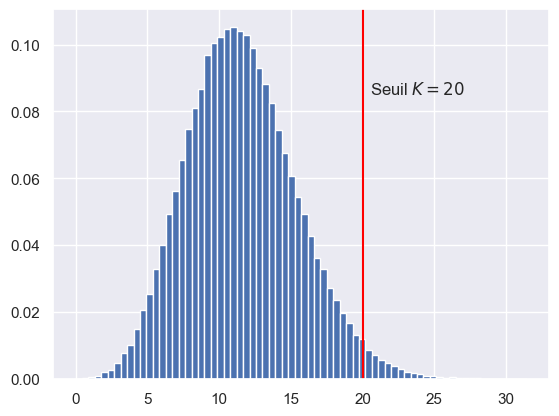

In [ ]:
sample_S = simu_S(int(1e5), mu, sigma, lambd)
K = 20

fig, ax = plt.subplots()
ax.hist(sample_S, bins=70, density=True)
ax.axvline(K, color='red')
ax.text(K+.5, 0.085, fr'Seuil $K={K}$', size=12)
plt.show()

## Estimateur Monte Carlo et erreur relative 

Soit $p_n = \displaystyle \frac{1}{n} \sum_{j=1}^n \mathbf{1}_{S^{(j)} > K}$ l'estimateur Monte Carlo de $p= \mathbf{P}\bigl[S > K\bigr]$ où $(S^{(j)})_{j=1,\dots,n}$ est une suite _i.i.d._ de même loi que $S$.

On rappelle que:

- l'**erreur absolue** de l'estimateur Monte Carlo $p_n$ est définie par $|p_n - p|$ et qu'avec probabilité 0.95 cette erreur est bornée par $e_n = 1.96 \frac{\sigma_n}{\sqrt{n}}$ avec $\sigma_n^2 = p_n - p_n^2$,
- l'**erreur relative** de l'estimateur Monte Carlo est définie par $\frac{|p_n - p|}{p}$ que l'on majore avec probabilité 0.95 par $\frac{e_n}{p_n}$.

### Question: erreur relative 

Ecrire une fonction `relative_error` qui à partir d'un échantillon de $S$ (de taille $n$) et d'une valeur de seuil $K$ renvoie la probabilité $p_n$ et l'erreur relative (plus exactement la borne $\frac{e_n}{p_n}$ à 95%). 

Tracer l'erreur relative d'un échantillon de taille $100\,000$ en fonction de $K$ pour $K$ allant de 20 à 30. Comment interpréter cette courbe? 

In [ ]:
def relative_error(sample, K):
    p_n = np.mean(sample > K)
    v_n = p_n - p_n**2   # ou np.var(sample > K) 
    e_n = 1.96 * np.sqrt(v_n / sample.size)
    return p_n, e_n / p_n

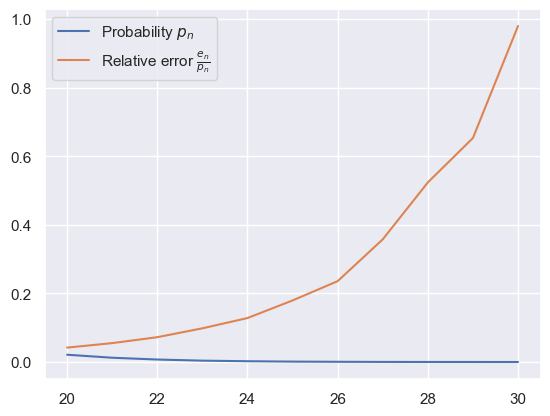

In [ ]:
Ks = np.arange(20, 31)
errors = np.array([relative_error(sample_S, K) for K in Ks])
fig, ax = plt.subplots()
ax.plot(Ks, errors)
ax.legend((r'Probability $p_n$',r'Relative error $\frac{e_n}{p_n}$'))
plt.show()

### Question: Monte Carlo à précision fixée

Mettre en oeuvre un estimateur de Monte Carlo qui s'arrête dès que l'erreur relative est de 5%. On pourra par exemple introduire la variable aléatoire

$$
    \tau^{(m)} = \inf \bigl\{n \ge 1, e_{n m} \le 0.05 p_{n m} \bigr\},
$$
qui dépend d'un paramètre $m$ fixé, par exemple $m = 10\,000$, et renvoyer $p_{\tau^{(m)}}$ ainsi que l'erreur relative et la taille de l'estimateur associé. 
Le paramètre $m$ permet de recalculer l'estimateur et l'erreur uniquement toutes les $m$ itérations et donc de réduire la complexité par rapport au choix naïf $m = 1$. On appelle ce paramètre $m$ la taille du _batch_ (`batch_size`). 
Le nombre d'itérations (la taille de l'échantillon) dans la méthode de Monte Carlo pour un $\tau^{(m)}$ donné est donc $\tau^{(m)} \times m$. 

Définir la fonction qui code cet estimateur Monte Carlo:
```
monte_carlo_relative(mu, sigma, lambd, K, batch_size = 10000, error = 0.05)
```

In [ ]:
def monte_carlo_relative(mu, sigma, lambd, K, batch_size = 10000, error = 0.05):
    sample_S = simu_S(batch_size, mu, sigma, lambd)
    while True:
        p_n, er_n = relative_error(sample_S, K)
        if er_n < error: 
            return p_n, er_n, len(sample_S)
        else:
            new_sample = simu_S(batch_size, mu, sigma, lambd)
            sample_S = np.append(sample_S, new_sample)

### Question: complexité en fonction de $K$

Reproduire un tableau de résultat similaire au tableau suivant obtenu avec cet estimateur de Monte Carlo adaptatif jusqu'à l'itération $\tau^{(m)} \times m$ pour une erreur relative de 10% et pour différentes valeurs de $K = 20,\dots,25$.  

Tracer le nombre d'itérations nécessaires en fonction de $K$.

In [ ]:
import pandas as pd
df = pd.read_pickle("data/iterations_df.pkl")
df

,Probabilité $p_n$,Erreur relative,Itérations
20,0.021600,0.093277,20000
21,0.013100,0.098219,30000
22,0.007820,0.098733,50000
23,0.003910,0.098927,100000
24,0.002259,0.099908,170000
25,0.001258,0.099186,310000


In [ ]:
Ks = np.arange(20, 26)
result = np.array([monte_carlo_relative(mu, sigma, lambd, K, error = 0.01) for K in Ks])

In [ ]:
import pandas as pd
res_df = pd.DataFrame(result, 
                      columns=("Probabilité $p_n$", "Erreur relative", "Itérations"), 
                      index = Ks)
res_df = res_df.astype({'Itérations': 'int'})
res_df
#res_df.to_pickle("data/iterations_df.pkl")  

,Probabilité $p_n$,Erreur relative,Itérations
20,0.021096,0.009979,1790000
21,0.012549,0.009988,3030000
22,0.007199,0.009998,5300000
23,0.004069,0.009996,9410000
24,0.002207,0.009999,17370000
25,0.001172,0.009999,32740000


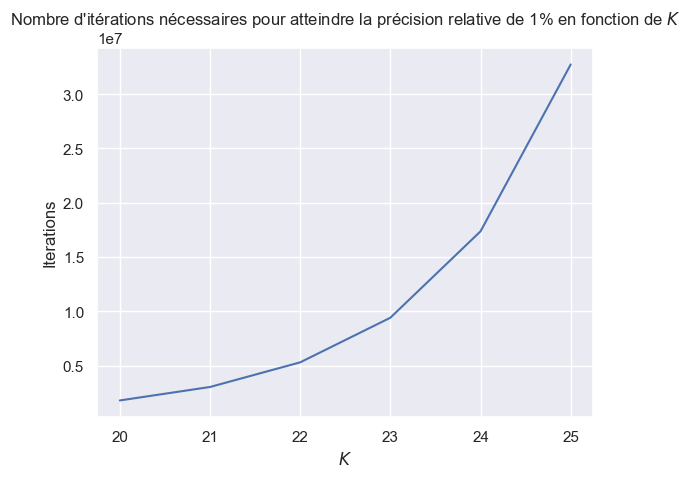

In [ ]:
fig, ax = plt.subplots()
ax.plot(Ks, res_df['Itérations'], label="Iterations")
ax.set_xlabel(r"$K$")
ax.set_ylabel(r"Iterations")
ax.set_title(r"Nombre d'itérations nécessaires pour atteindre la précision relative de 1% en fonction de $K$")
plt.show()

## Réduction de variance par préconditionnement 

Pour réduire la variance on utilise d'abord une méthode de préconditionnement, c'est à dire qu'on considère la variable aléatoire 

$$
    M = \inf \bigl\{ r \ge 1, \sum_{i=1}^r X_i > K \bigr\}
$$
et la représentation suivante

$$
    p = \mathbf{E} \bigl[\phi(M) \bigr] \quad \text{avec} \quad \phi(m) = \mathbf{P} \bigl[ N \ge m \bigr].
$$

### Question: simulation de $M$ 

Ecrire une fonction `simu_M` similaire à la fonction `simu_S` avec l'argument $K$ supplémentaire qui renvoie un échantillon _i.i.d._ de même loi que $M$. 

In [ ]:
def simu_M_non_opt(size, mu, sigma, K): 
    sample_M = np.empty(size) 
    for k in range(size): 
        sum_Xi = rng.lognormal(size=1, mean=mu, sigma = sigma)
        r = 1
        while sum_Xi <= K:
            sum_Xi += rng.lognormal(size=1, mean=mu, sigma = sigma)
            r += 1
        sample_M[k] = r
    return sample_M 

# la fonction précédente est correcte mais trop lente car il y a de très 
# nombreux appels successifs au générateur de taille size=1 ce qui est 
# à éviter. voici une version plus optimisée 

def simu_M(size, mu, sigma, K, batch_size=20): 
    sample_M = np.empty(size) 
    for k in range(size):  
        sample_x = np.zeros(1)
        while True:
            sample_x = np.append(sample_x, 
                                 rng.lognormal(size=batch_size, mean=mu, sigma = sigma))
            r = np.argmax(np.cumsum(sample_x) > K)
            if r > 0: break 
        sample_M[k] = r
    return sample_M

# exercice: faire un code similaire sans "grossir" sample_x avec np.append

In [ ]:
mu, sigma

(0.1, 0.3)

In [ ]:
%timeit simu_M_non_opt(100000, mu, sigma, K=25)
%timeit simu_M(100000, mu, sigma, K=25)

1.92 s ± 4.53 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
494 ms ± 577 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Question: Monte Carlo et ratio de variance 

En utilisant la fonction `monte_carlo` du TP précédent. Calculer le ratio de variance entre l'estimateur $p_n$ et l'estimateur basé sur la représentation $p = \mathbf{E}[\phi(M)]$ où $\phi$ est calculée en utilisant la fonction de survie et la fonction de masse de la loi de Poisson (cf. la documentation de `stats.poisson`). Faire ce calcul pour différentes valeurs de $K$ et $n = 100\,000$

In [ ]:
def monte_carlo(sample, proba = 0.95):
    """
    Computes the mean, variance, and a 95% confidence interval of a 
    given sample data set using the Monte Carlo method.
    Parameters:
    -----------
    sample : array-like
        The data set to be analyzed
    proba : float, optional
        The probability that the true mean of the population is 
        within the calculated interval. Default is 0.95
    Returns:
    --------
    tuple : float
        The mean, variance, lower bound of the 95% CI and upper bound of the 95% CI
    """
    mean = np.mean(sample)
    var = np.var(sample, ddof=1)
    alpha = 1 - proba 
    quantile = stats.norm.ppf(1 - alpha/2)  # fonction quantile 
    ci_size = quantile * np.sqrt(var / sample.size)
    return {
        "mean": mean, 
        "var": var, 
        "lower": mean - ci_size, 
        "upper": mean + ci_size
    }

In [ ]:
# estimateur naif 
size = int(1e5)
Ks = np.arange(20,26)
sample_S = simu_S(size, mu, sigma, lambd)
result = [ monte_carlo(sample_S > K) for K in Ks ]
import pandas as pd
res_df = pd.DataFrame(result, index=Ks)
res_df

,mean,var,lower,upper
20,0.02129,0.020837,0.020395,0.022185
21,0.01268,0.012519,0.011987,0.013373
22,0.00715,0.007099,0.006628,0.007672
23,0.00418,0.004163,0.003780,0.004580
24,0.00228,0.002275,0.001984,0.002576
25,0.00119,0.001189,0.000976,0.001404


In [ ]:
def phi(m, lambd = 10):
    N = stats.poisson(mu = lambd)
    return N.pmf(m) + N.sf(m) # ou N.pmf(m-1)

In [ ]:
result = [] 
for K in Ks:
    sample_M = simu_M(size, mu, sigma, K)
    result.append(monte_carlo(phi(sample_M)))
import pandas as pd
res_df_precond = pd.DataFrame(result, index=Ks)
res_df_precond

,mean,var,lower,upper
20,0.021318,0.000359,0.021201,0.021436
21,0.012572,0.000156,0.012495,0.012650
22,0.007250,0.000065,0.007200,0.007300
23,0.004055,0.000025,0.004024,0.004086
24,0.002194,0.000009,0.002176,0.002213
25,0.001163,0.000003,0.001152,0.001174


In [ ]:
res_df["var"] / res_df_precond["var"]

20     58.104533
21     80.271775
22    109.462796
23    166.331576
24    252.643736
25    387.117945
Name: var, dtype: float64

## Réduction de variance par échantillonage d'importance

Pour réduire la variance sans faire exploser la complexité pour les grandes valeurs de $K$ on propose une méthode d'échantillonage d'importance (Importance Sampling) en modifiant la loi de la variable aléatoire $N$ (on peut faire un autre choix, en changeant la loi des $X_i$ ou bien en changeant la loi de $N$ et des $X_i$). Le changement de loi proposé ici repose sur le changement de probabilité, pour $\theta \in \mathbf{R}$

$$
    \frac{\mathrm{d} \mathbf{P}}{\mathrm{d} \mathbf{P}_\theta} = L_\theta \quad \text{avec} \quad L_\theta = \exp\bigl(-\theta N + \psi(\theta) \bigr),
$$
où $\psi(\theta) = \log \mathbf{E} \bigl[ \exp(\theta N) \bigr] = \lambda (e^\theta - 1)$. On vérifie par le calcul que la loi de $N$ sous $\mathbf{P}_\theta$ est la loi de Poisson de paramètre $\tilde \lambda = \lambda e^\theta$. Ainsi on a la représentation 

$$
    \mathbf{P}\biggl[ \sum_{i=1}^N X_i > K \biggr] 
    = \mathbf{E}_{\mathbf{P}_\theta} \biggl[ 
    \mathbf{1}_{\sum_{i=1}^N X_i > K } \exp\big(-\theta N+\psi(\theta)\big)
    \bigg]
    \quad \text{avec $N \sim \mathcal{P}(\tilde \lambda)$ sous $\mathbf{P}_\theta$}.
$$

Il est d'usage pour la loi de Poisson d'écrire la variable $L_\theta$ à partir de $\lambda$ et $\tilde \lambda$ (la valeur du paramètre de la loi de Poisson sous la nouvelle probabilité) _i.e._ 

$$
    L_\theta = \exp\big(-\theta N + \lambda(e^\theta - 1)\big) 
    = \Bigl(\frac{\lambda}{\tilde \lambda}\Big)^N \exp\big(\tilde \lambda - \lambda\big).
$$

### Question: simulation sous $\mathbf{P}_\theta$ 

La loi de $N$ sous $\mathbf{P}_\theta$ est la loi de Poisson de paramètre $\tilde \lambda=\lambda e^\theta$ et la suite $(X_i)_{i \ge 1}$ est indépendante de $N$ donc de $L_\theta$ et n'est donc pas impactée par le changement de probabilité: la loi des $(X_i)_{i \ge 1}$ est inchangée.  
Ecrire une fonction `simu_S_tilde` inspirée de `simu_S` qui prend un paramètre supplémentaire $\theta$ et qui renvoie un échantillon de $\sum_{i=1}^{N} X_i$ sous $\mathbf{P}_\theta$.

In [ ]:
def simu_S_tilde(size, mu, sigma, lambd, theta): 
    sample_N_tilde = rng.poisson(size=size, lam=lambd * np.exp(theta))
    sample_sum = np.empty(size)
    for k, Nk in enumerate(sample_N_tilde):
        sample_sum[k] = np.sum(rng.lognormal(size=Nk, mean=mu, sigma = sigma))
    return sample_sum

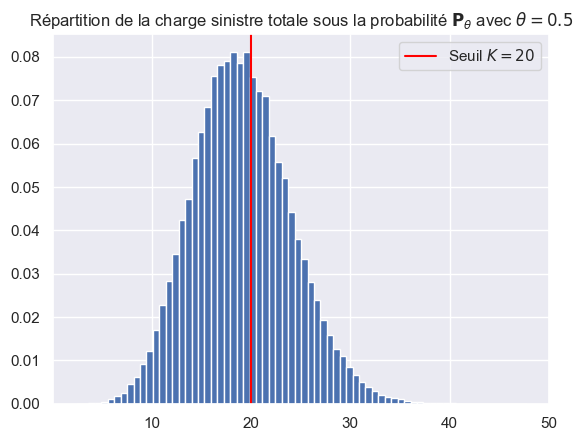

In [ ]:
theta = 0.5
sample_S = simu_S_tilde(int(1e5), mu, sigma, lambd, theta=theta)
K = 20

fig, ax = plt.subplots()
ax.hist(sample_S, bins=70, density=True)
ax.axvline(K, color='red', label=fr'Seuil $K={K}$')
ax.set_title(fr"Répartition de la charge sinistre totale sous la probabilité $\mathbf{{P}}_\theta$ avec $\theta = {theta}$")
ax.legend()
plt.show()

### Question: Monte Carlo sous $\mathbf{P}_\theta$

Comparer pour différentes valeurs de $K$, avec $\theta = 0.7$, l'estimateur de Monte Carlo basé sur la représentation 

$$
    \mathbf{P}\biggl[ \sum_{i=1}^N X_i > K \biggr] 
    = \mathbf{E}\biggl[\mathbf{1}_{\sum_{i=1}^{\tilde N} X_i > K } 
    \bigl(\frac{\lambda}{\tilde \lambda} \bigr)^{\tilde N} 
    \exp(\tilde \lambda - \lambda)
    \biggr] \quad \text{avec $\tilde N \sim \mathcal{P}(\tilde \lambda)$}.
$$

Pour $K = 22$ le ratio de variance est de l'ordre de 16-17.

Que se passe-t-il si le paramètre $\theta$ est mal choisi? (prendre par exemple $\theta = 1.2$ puis $\theta = 1.5$, et $\theta = -0.1$...)

In [ ]:
# on modifie un peu la fonction précédente car on a besoin de N_tilde !
def simu_sous_P_tilde(size, mu, sigma, lambd, theta): 
    sample_N_tilde = rng.poisson(size=size, lam=lambd * np.exp(theta))
    sample_sum = np.empty(size)
    for k, Nk in enumerate(sample_N_tilde):
        sample_sum[k] = np.sum(rng.lognormal(size=Nk, mean=mu, sigma = sigma))
    return sample_sum, sample_N_tilde

In [ ]:
Ks = np.arange(20,26)
theta = 0.7

lambd_tilde = lambd * np.exp(theta)
sample_S_tilde, sample_N_tilde = simu_sous_P_tilde(int(1e5), mu, sigma, lambd, theta)
result = []
for K in Ks:
    sample = (sample_S_tilde > K) * (lambd / lambd_tilde)**sample_N_tilde * np.exp(lambd_tilde - lambd)
    result.append(monte_carlo(sample))
    
import pandas as pd
res_df_is = pd.DataFrame(result, index=Ks)
res_df_is

,mean,var,lower,upper
20,0.021179,0.003305,0.020823,0.021536
21,0.012347,0.001108,0.012141,0.012553
22,0.007218,0.000445,0.007087,0.007348
23,0.004034,0.000164,0.003954,0.004113
24,0.002202,0.000052,0.002157,0.002247
25,0.001169,0.000019,0.001142,0.001196


In [ ]:
res_df["var"] / res_df_is["var"]

20     6.304561
21    11.296313
22    15.936351
23    25.337661
24    43.883639
25    62.671894
Name: var, dtype: float64